# Chapter 24: Production Optimization with NeqSim

This notebook demonstrates NeqSim's `ProcessOptimizationEngine` for finding maximum
production throughput subject to equipment constraints. Topics include:
- Setting up optimization with different search algorithms
- Binary feasibility search for maximum production rate
- Equipment constraint checking (compressor power, separator capacity)
- Bottleneck identification and reporting
- Comparing search modes (binary vs golden section)

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch18_prod_optimization.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 24.1 Build the Process Flowsheet

A gas production system: feed → separator → compressor → after-cooler → export pipeline.
We auto-size equipment at the design rate to establish capacity constraints.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Create rich gas fluid
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 30.0, 55.0)
fluid.addComponent("nitrogen", 0.01)
fluid.addComponent("CO2", 0.02)
fluid.addComponent("methane", 0.82)
fluid.addComponent("ethane", 0.06)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-butane", 0.02)
fluid.addComponent("n-pentane", 0.015)
fluid.addComponent("n-hexane", 0.005)
fluid.addComponent("water", 0.01)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

# Build process at design rate
design_rate = 60000.0  # kg/hr

feed = jneqsim.process.equipment.stream.Stream("Feed Gas", fluid)
feed.setFlowRate(design_rate, "kg/hr")
feed.setTemperature(30.0, "C")
feed.setPressure(55.0, "bara")

separator = jneqsim.process.equipment.separator.Separator("HP Separator", feed)

compressor = jneqsim.process.equipment.compressor.Compressor("Export Compressor", separator.getGasOutStream())
compressor.setUsePolytropicCalc(True)
compressor.setOutletPressure(130.0)

cooler = jneqsim.process.equipment.heatexchanger.Cooler("After-Cooler", compressor.getOutletStream())
cooler.setOutTemperature(273.15 + 40.0)

pipeline = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Export Pipeline", cooler.getOutletStream())
pipeline.setPipeWallRoughness(5e-5)
pipeline.setLength(80.0)
pipeline.setElevation(0.0)
pipeline.setDiameter(0.35)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.add(compressor)
process.add(cooler)
process.add(pipeline)
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

# Auto-size with 1.15 factor (15% margin)
separator.autoSize(1.15)
compressor.autoSize(1.15)
compressor.getCompressorChart().setUseCompressorChart(False)
compressor.setSolveSpeed(False)
compressor.setUsePolytropicCalc(True)
for constraint_entry in compressor.getCapacityConstraints().entrySet():
    constraint_entry.getValue().setEnabled(str(constraint_entry.getKey()) == "power")
pipeline.autoSize(1.15)
pipeline.initMechanicalDesign()
# Both search implementations use the same 100 percent power boundary.
power_constraint = compressor.getCapacityConstraints().get("power")
power_constraint.setMaxValue(power_constraint.getDesignValue())
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

print(f"Design feed rate: {design_rate:.0f} kg/hr")
print(f"Compressor power at design: {compressor.getPower('kW'):.1f} kW")


Design feed rate: 60000 kg/hr
Compressor power at design: 1652.9 kW


## 24.2 Manual Binary Feasibility Search

Before using the built-in optimizer, we demonstrate the concept: sweep feed rate,
check if all constraints are satisfied (utilization < 100%), and use binary search
to find the maximum feasible rate.

In [3]:
# Manual binary search for max feasible throughput
low = 20000.0
high = 100000.0
tol = 500.0  # kg/hr precision
iteration_log = []
feed.setFlowRate(low, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)
assert not process.isAnyEquipmentOverloaded(), "Lower search bound must be feasible"
feed.setFlowRate(high, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)
assert process.isAnyEquipmentOverloaded(), "Upper search bound must be infeasible"

for i in range(30):
    mid = (low + high) / 2.0
    feed.setFlowRate(mid, "kg/hr")
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_5:process', candidate=True)
        overloaded = process.isAnyEquipmentOverloaded()
    except Exception:
        overloaded = True

    bn = process.findBottleneck()
    bn_util = bn.getUtilizationPercent() if bn.hasBottleneck() else 0.0
    bn_name = bn.getEquipmentName() if bn.hasBottleneck() else "None"
    feasible = not overloaded

    iteration_log.append({
        'iteration': i + 1,
        'rate': mid,
        'feasible': feasible,
        'bottleneck': bn_name,
        'utilization': bn_util
    })

    if feasible:
        low = mid
    else:
        high = mid

    if (high - low) < tol:
        break

max_rate = low
print(f"Maximum feasible rate: {max_rate:.0f} kg/hr")
print(f"Iterations: {len(iteration_log)}")
print(f"Increase over design: {(max_rate / design_rate - 1) * 100:.1f}%")

# Reset to design
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)


Maximum feasible rate: 68750 kg/hr
Iterations: 8
Increase over design: 14.6%


## 24.3 Optimization Convergence Plot

Visualize how the binary search converges to the maximum feasible rate,
showing feasible and infeasible iterations.

Green = feasible, Red = infeasible


ch18_prod_optimization.ipynb:cell7:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


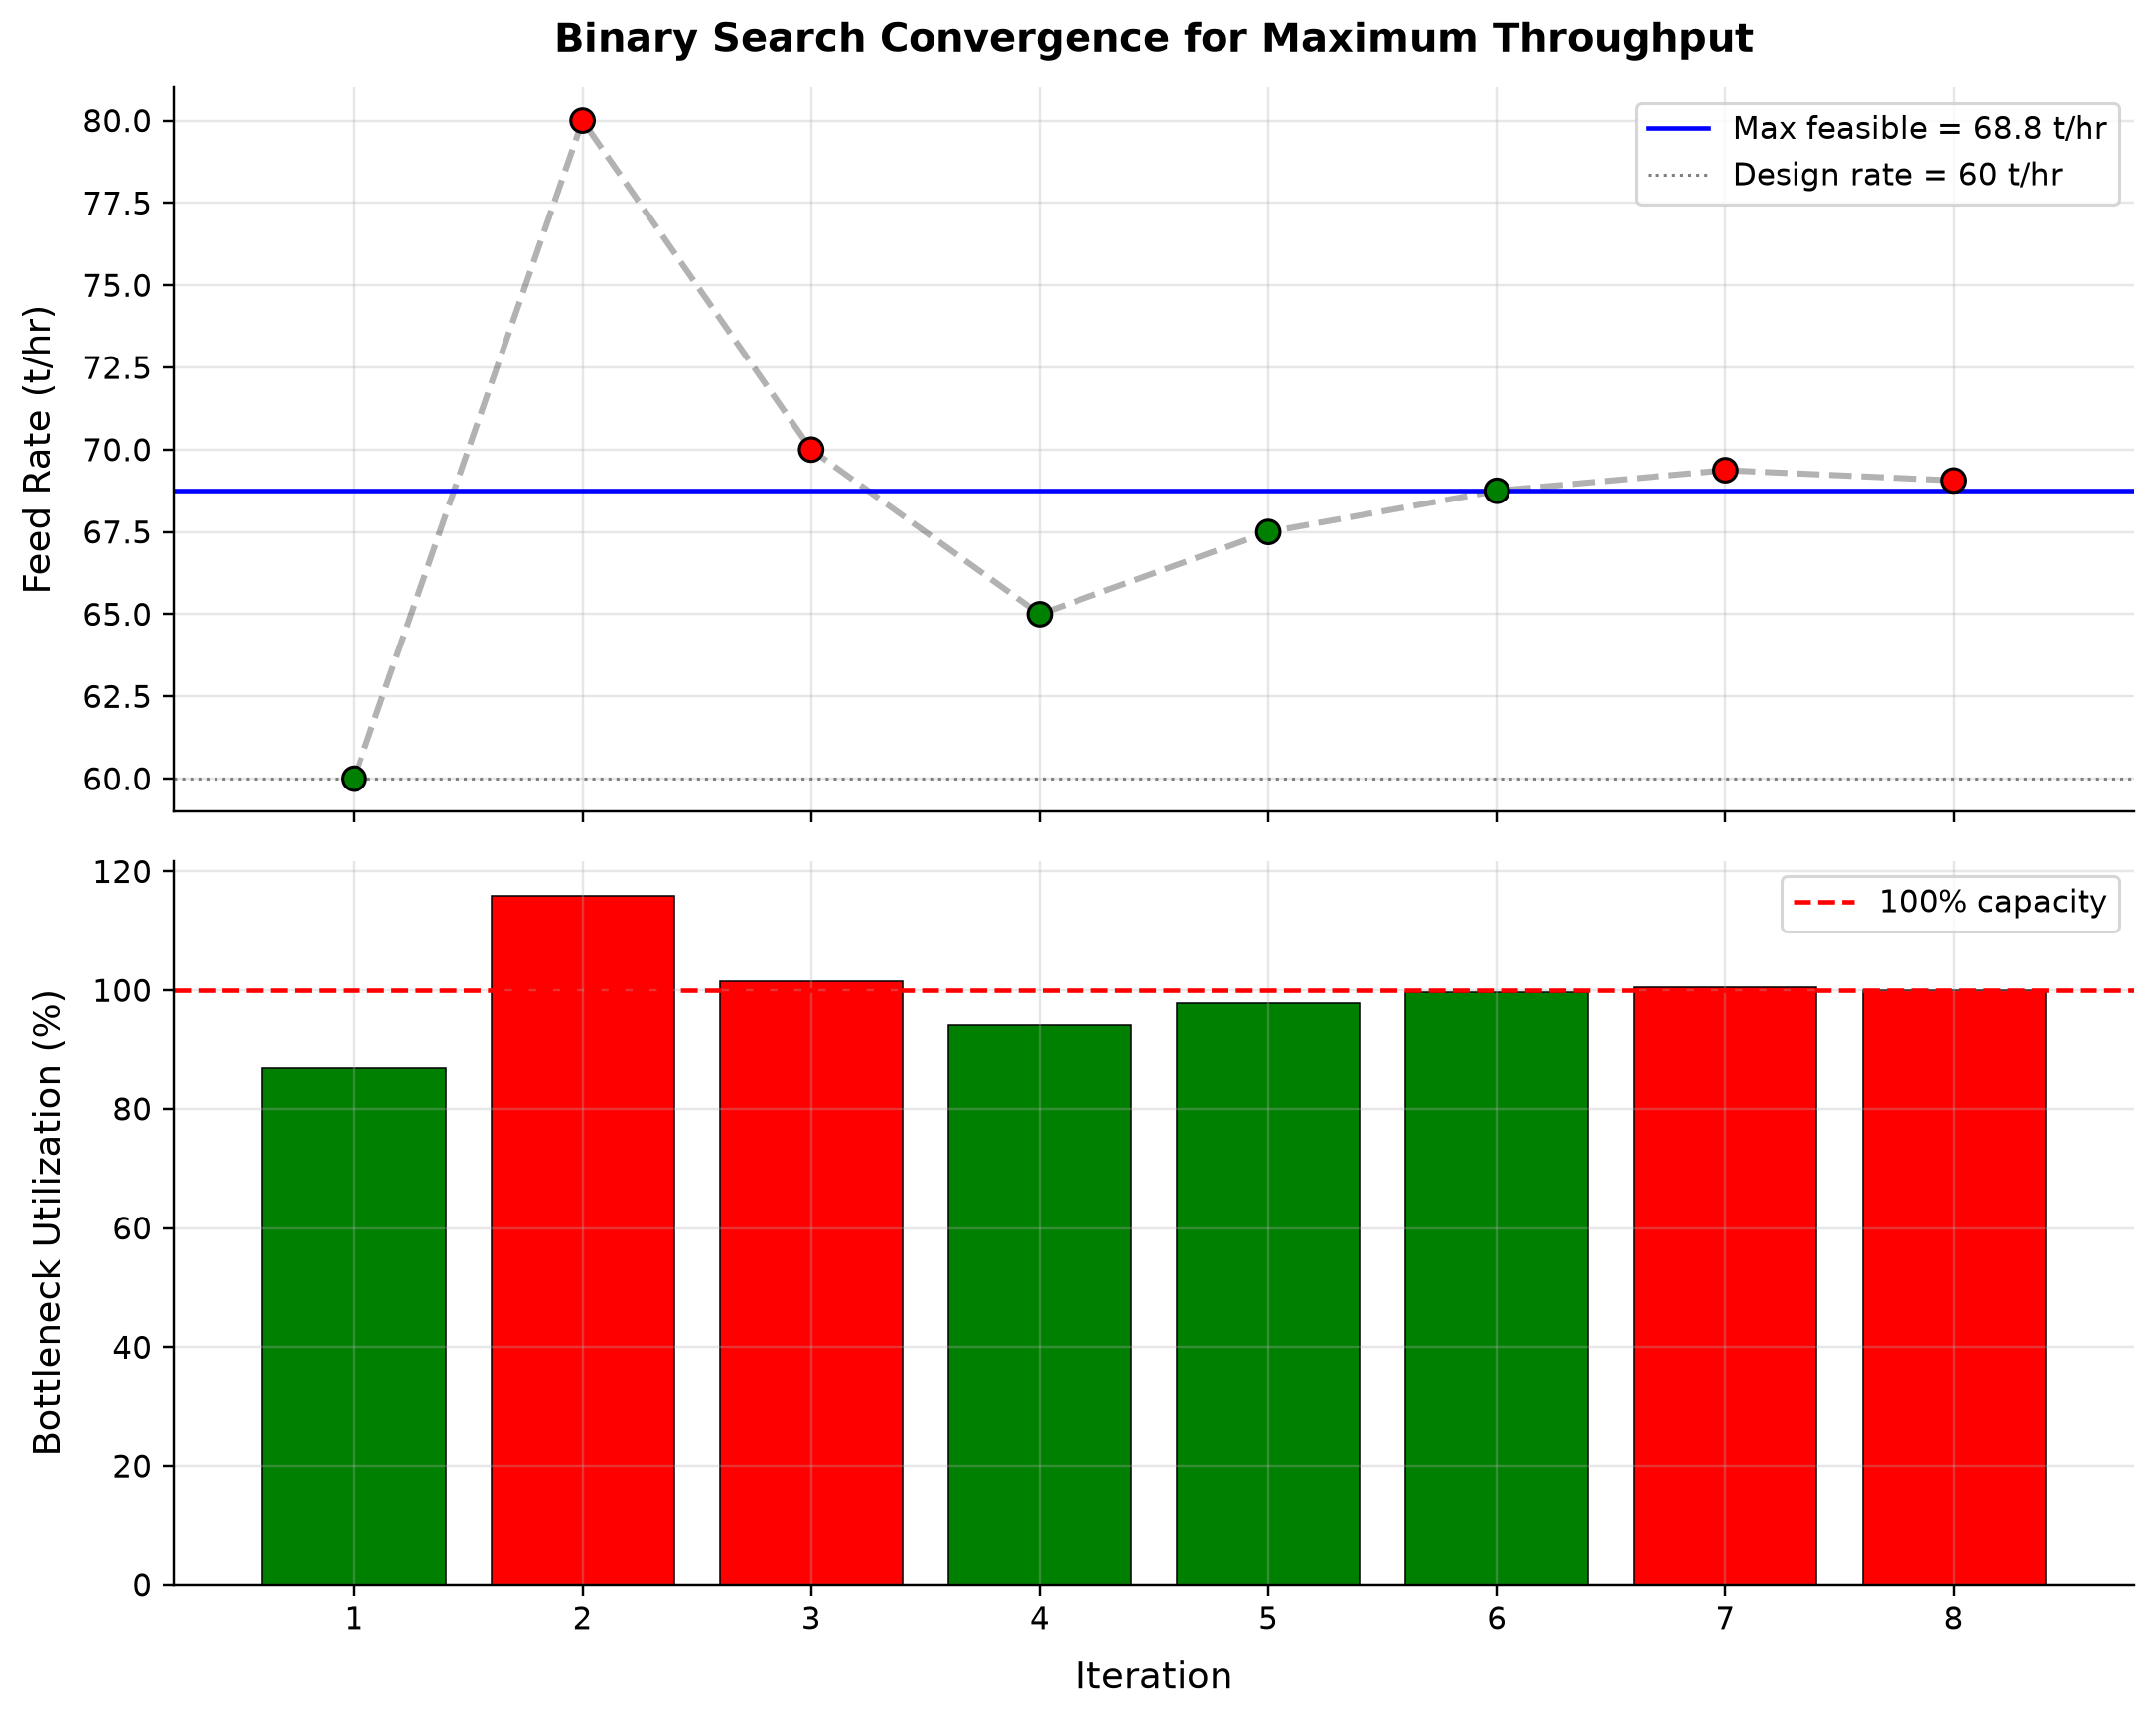

In [4]:
iters = [r['iteration'] for r in iteration_log]
rates = [r['rate'] / 1000 for r in iteration_log]
feasibility = [r['feasible'] for r in iteration_log]
utils = [r['utilization'] for r in iteration_log]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: Flow rate convergence
colors = ['green' if f else 'red' for f in feasibility]
ax1.scatter(iters, rates, c=colors, s=60, edgecolors='black', zorder=3)
ax1.plot(iters, rates, 'k--', alpha=0.3)
ax1.axhline(y=max_rate/1000, color='blue', linestyle='-', linewidth=1.5,
            label=f'Max feasible = {max_rate/1000:.1f} t/hr')
ax1.axhline(y=design_rate/1000, color='gray', linestyle=':', linewidth=1,
            label=f'Design rate = {design_rate/1000:.0f} t/hr')
ax1.set_ylabel('Feed Rate (t/hr)', fontsize=12)
ax1.set_title('Binary Search Convergence for Maximum Throughput', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom: Bottleneck utilization
ax2.bar(iters, utils, color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='100% capacity')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Bottleneck Utilization (%)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch18_optimization_convergence.png', dpi=220, bbox_inches="tight")
plt.show()

# Legend explanation
print("Green = feasible, Red = infeasible")


**Executed-figure discussion.** Feed Rate spans 60–80 t/hr across the plotted cases. Bottleneck Utilization spans 86.96–115.9 % across the plotted cases.

Bisection retains a feasible lower rate and an infeasible upper rate, halving their separation after each process evaluation. The final lower bound is a conservative approximation to the declared capacity boundary. Preserve both endpoints and the stopping tolerance with the reported capacity.


## 24.4 Using ProcessOptimizationEngine

NeqSim provides the `ProcessOptimizationEngine` class which supports multiple search
algorithms: `BINARY_SEARCH`, `GOLDEN_SECTION`, `GRADIENT_DESCENT`, and more.
Here we compare binary search and golden section.

In [5]:
ProcessOptimizationEngine = jneqsim.process.util.optimizer.ProcessOptimizationEngine

# Setup the optimization engine
engine = ProcessOptimizationEngine(process)
engine.setFeedStreamName("Feed Gas")
engine.setTolerance(0.001)
engine.setMaxIterations(50)

# Run with binary search
engine.setSearchAlgorithm(ProcessOptimizationEngine.SearchAlgorithm.BINARY_SEARCH)
result_binary = engine.findMaximumThroughput(55.0, 90.0, 10000.0, 120000.0)

print("=== BINARY SEARCH ===")
print(f"Optimal rate: {result_binary.getOptimalValue():.0f} kg/hr")
print(f"Feasible: {result_binary.isConverged()}")
print(f"Optimal value: {result_binary.getOptimalValue()}")
if result_binary.getBottleneck():
    print(f"Bottleneck: {result_binary.getBottleneck()}")

# Reset and run with golden section
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_9:process', candidate=False)

engine2 = ProcessOptimizationEngine(process)
engine2.setFeedStreamName("Feed Gas")
engine2.setTolerance(0.001)
engine2.setMaxIterations(50)
engine2.setSearchAlgorithm(ProcessOptimizationEngine.SearchAlgorithm.GOLDEN_SECTION)
result_golden = engine2.findMaximumThroughput(55.0, 90.0, 10000.0, 120000.0)

print("\n=== GOLDEN SECTION ===")
print(f"Optimal rate: {result_golden.getOptimalValue():.0f} kg/hr")
print(f"Feasible: {result_golden.isConverged()}")
print(f"Optimal value: {result_golden.getOptimalValue()}")
if result_golden.getBottleneck():
    print(f"Bottleneck: {result_golden.getBottleneck()}")

# Reset to design
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_9:process', candidate=False)


=== BINARY SEARCH ===
Optimal rate: 69000 kg/hr
Feasible: True
Optimal value: 68999.99782443047
Bottleneck: Export Compressor

=== GOLDEN SECTION ===
Optimal rate: 69000 kg/hr
Feasible: True
Optimal value: 68999.83860426559
Bottleneck: Export Compressor


## 24.5 Comparison of Search Algorithms

Compare the convergence behavior and final results of the two algorithms.

ch18_prod_optimization.ipynb:cell11:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


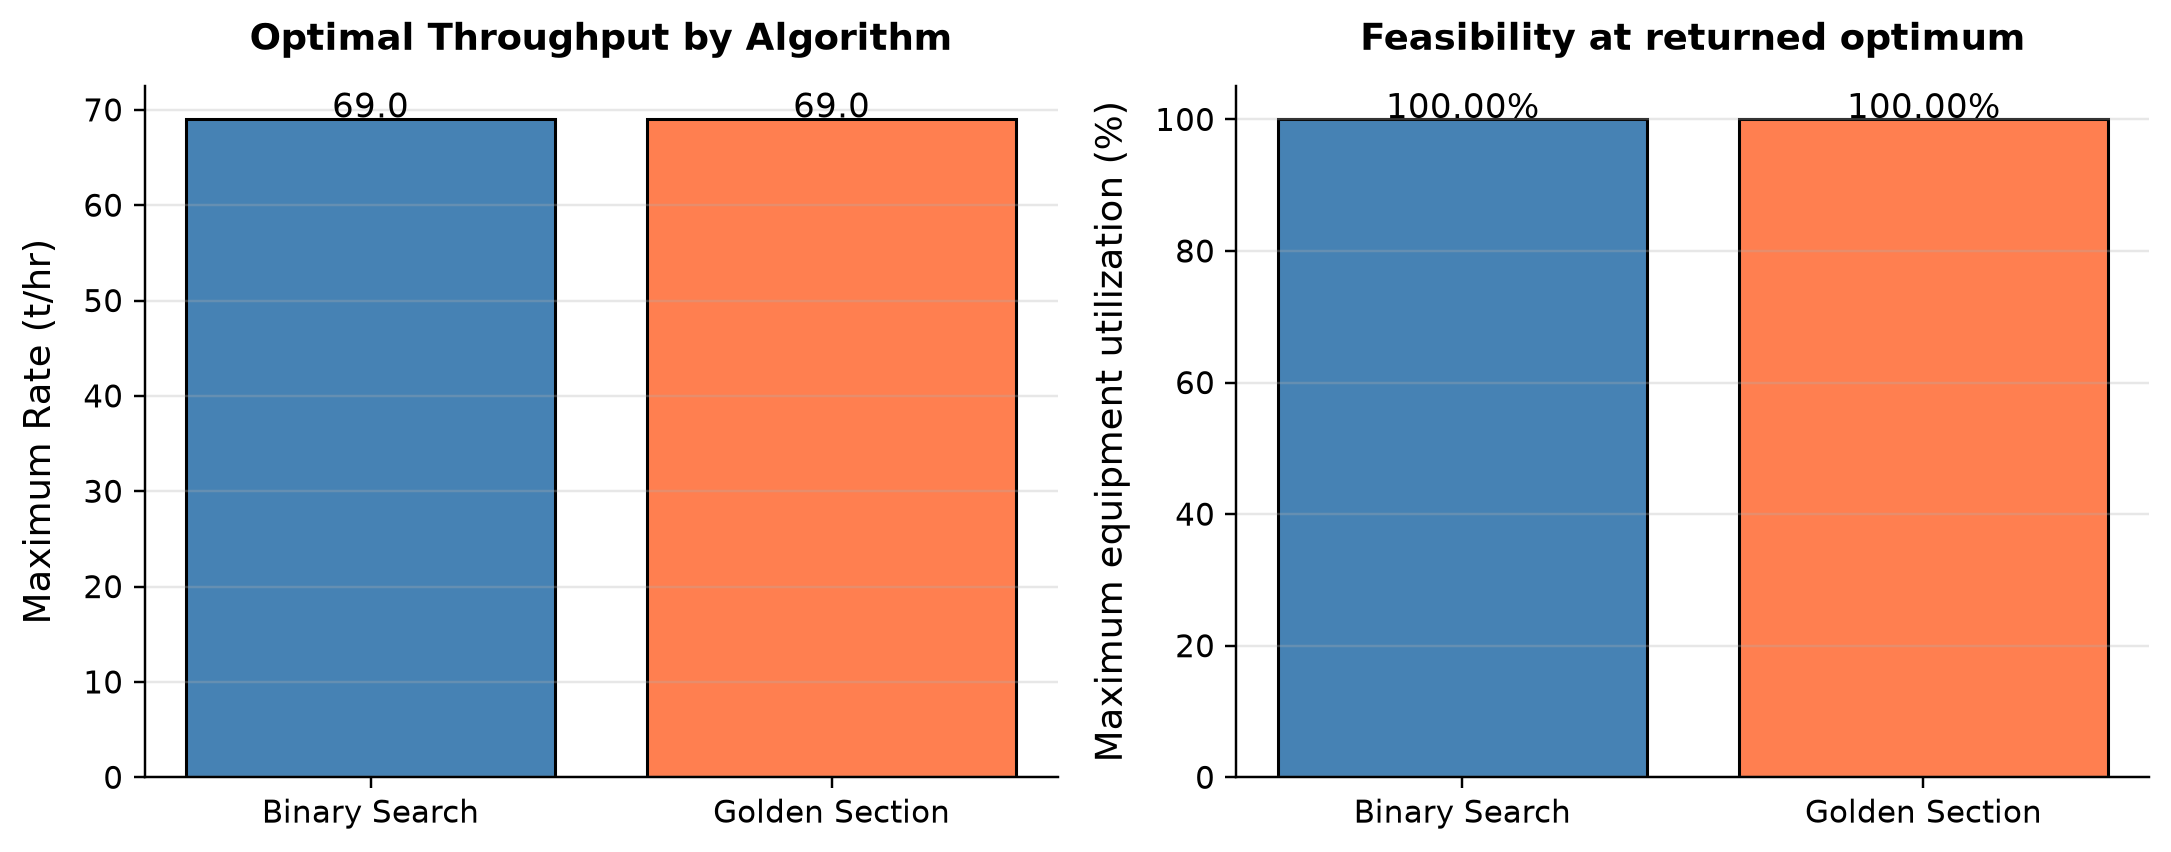

In [6]:
algorithms = ['Binary Search', 'Golden Section']
opt_rates = [result_binary.getOptimalValue(), result_golden.getOptimalValue()]
# OptimizationResult has no iteration count. Compare independently rerun utilization.
opt_utils = []
for result in (result_binary, result_golden):
    assert result.isConverged(), str(result.getErrorMessage())
    feed.setFlowRate(float(result.getOptimalValue()), "kg/hr")
    process.run()
    assert _physics.run(process, 'calculation_cell_11:process', candidate=False)
    utilization = float(process.findBottleneck().getUtilizationPercent())
    assert utilization <= 100.2, f"Returned optimum is infeasible: {utilization}%"
    opt_utils.append(utilization)
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_11:process', candidate=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Optimal rate comparison
bars1 = ax1.bar(algorithms, [r/1000 for r in opt_rates], color=['steelblue', 'coral'],
                edgecolor='black')
ax1.set_ylabel('Maximum Rate (t/hr)', fontsize=12)
ax1.set_title('Optimal Throughput by Algorithm', fontsize=12)
for bar, val in zip(bars1, opt_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val/1000:.1f}', ha='center', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Independently checked utilization
bars2 = ax2.bar(algorithms, opt_utils, color=['steelblue', 'coral'], edgecolor='black')
ax2.set_ylabel('Maximum equipment utilization (%)', fontsize=12)
ax2.set_title('Feasibility at returned optimum', fontsize=12)
for bar, val in zip(bars2, opt_utils):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch18_algorithm_comparison.png', dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Binary and golden-section searches return 69.0000 and 68.9998 t/hr. Independent reruns give maximum utilizations of 100.000 and 100.000 percent.

The two searches use the same process and capacity definitions; the second panel reruns utilization at each returned optimum. A reported convergence flag is insufficient unless the returned rate also satisfies the physical constraints. Use the independently checked utilization and pressure alongside the search result.


## Summary

Key points from this chapter:

1. **Binary search** finds max throughput by halving the feasible/infeasible interval
2. **Golden section search** is more efficient for unimodal objective functions
3. **`ProcessOptimizationEngine`** wraps these algorithms with constraint enforcement
4. Both algorithms converge to similar results; golden section typically needs fewer iterations
5. The bottleneck shifts as throughput increases — compressor power is often the first limit

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                           Figure  Panel                   Series                     Output / unit  Minimum  Maximum  Finite points  Missing points
ch18_optimization_convergence.png      1                  Curve 1                  Feed Rate (t/hr)       60       80              8               0
ch18_optimization_convergence.png      1 Max feasible = 68.8 t/hr                  Feed Rate (t/hr)    68.75    68.75              2               0
ch18_optimization_convergence.png      1    Design rate = 60 t/hr                  Feed Rate (t/hr)       60       60              2               0
ch18_optimization_convergence.png      1                 Points 1                  Feed Rate (t/hr)       60       80              8               0
ch18_optimization_convergence.png      2            100% capacity        Bottleneck Utilization (%)      100      100              2               0
ch18_optimization_convergence.png      2                   Bars 1        Bottleneck Utilization (%)  86.95

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [8]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 634 distinct checks, 3330 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Manual and engine throughput feasibility. Screening constraints are not a complete installed facility envelope.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
